1)Model loading

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

2)loading the dataset  and preforming basic data operation

In [4]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

Dataset shape: (569, 30)
Target shape: (569,)


In [5]:
print(data.target_names)
print(y.value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [6]:
print(X.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [7]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [8]:
print(X.describe())

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

3) VISUALIZE THE DATA SET

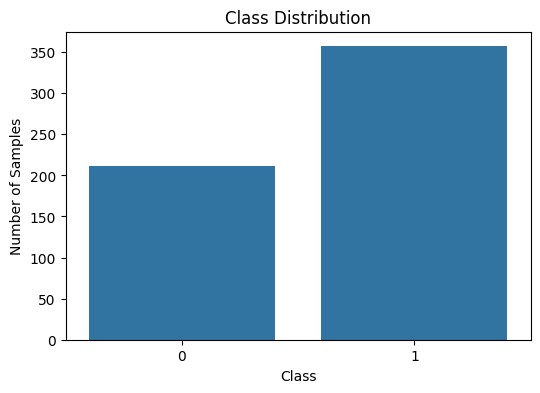

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

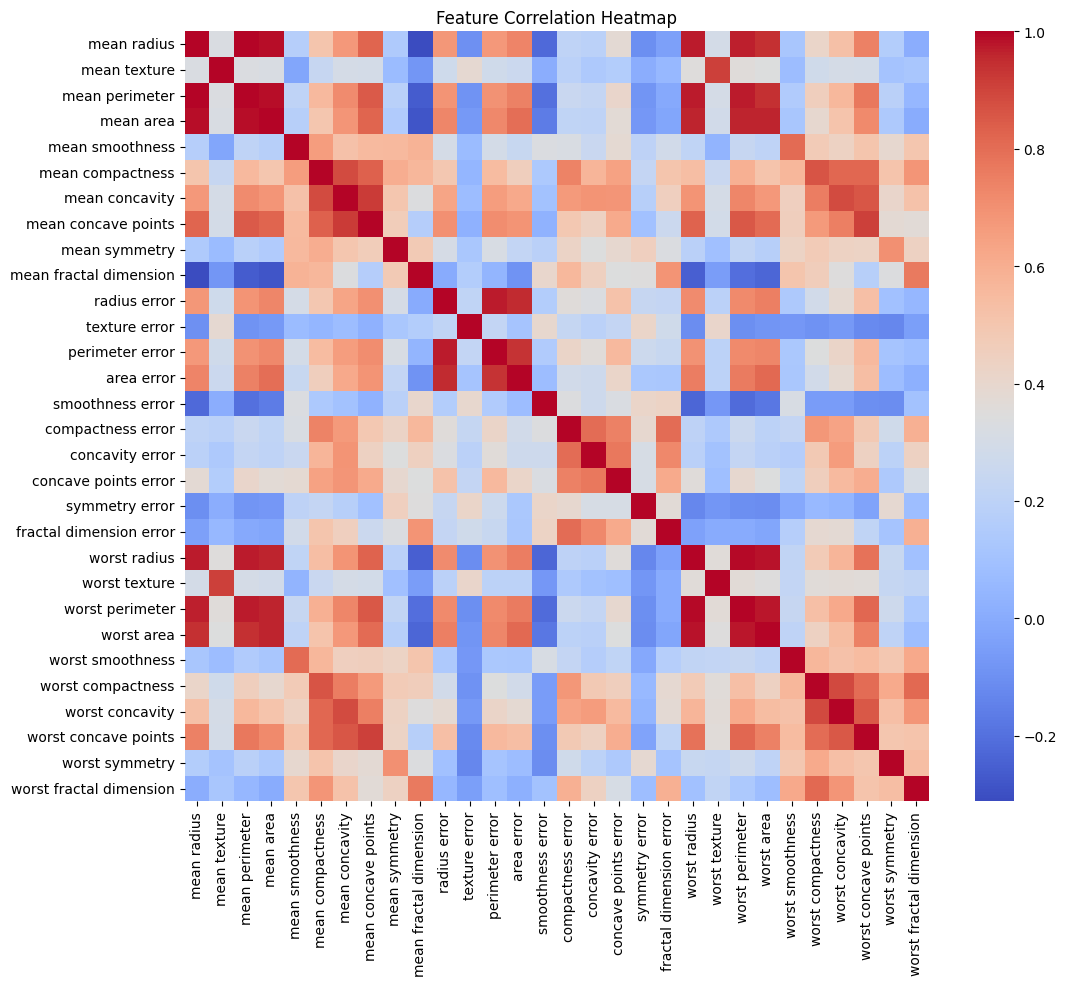

In [10]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Correlation Heatmap")
plt.show()

4) SPLIITING THE DATASET INTO TRAIN AND TEST

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


5)IMPLEMANTING BAGGING


In [12]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=10,
    max_samples=0.8,
    max_features=1.0,
    random_state=42
)

bagging_model.fit(X_train, y_train)

y_pred_bagging = bagging_model.predict(X_test)

print("Bagging Accuracy:",
      accuracy_score(y_test, y_pred_bagging))

Bagging Accuracy: 0.9385964912280702


In [13]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_bagging))

print("Precision:",
      precision_score(y_test, y_pred_bagging))

print("Recall:",
      recall_score(y_test, y_pred_bagging))

print("F1 Score:",
      f1_score(y_test, y_pred_bagging))

Accuracy: 0.9385964912280702
Precision: 0.9577464788732394
Recall: 0.9444444444444444
F1 Score: 0.951048951048951


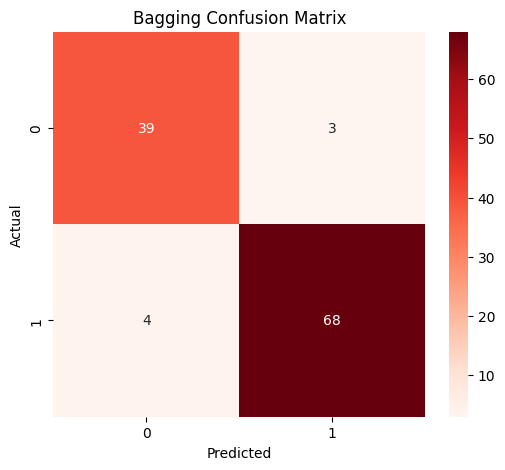

In [14]:
cm = confusion_matrix(y_test, y_pred_bagging)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bagging Confusion Matrix")
plt.show()

6)BAGGING HYPERPARAMETER

In [15]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

bagging_params = {
    "n_estimators": [5, 10, 20],
    "max_samples": [0.6, 0.8, 1.0],
    "max_features": [0.5, 0.8, 1.0]
}

bagging_grid = GridSearchCV(
    estimator=bagging,
    param_grid=bagging_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

bagging_grid.fit(X_train, y_train)

,estimator,BaggingClassi...ndom_state=42)
,param_grid,"{'max_features': [0.5, 0.8, ...], 'max_samples': [0.6, 0.8, ...], 'n_estimators': [5, 10, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [16]:
print("Best Parameters:")
print(bagging_grid.best_params_)

print("Best CV Accuracy:")
print(bagging_grid.best_score_)

Best Parameters:
{'max_features': 0.8, 'max_samples': 1.0, 'n_estimators': 20}
Best CV Accuracy:
0.9582417582417582


7) BOOSTING ADABOOST

In [17]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

adaboost_model.fit(X_train, y_train)

y_pred_ada = adaboost_model.predict(X_test)

In [18]:
print("AdaBoost Accuracy:",
      accuracy_score(y_test, y_pred_ada))

print("AdaBoost Precision:",
      precision_score(y_test, y_pred_ada))

print("AdaBoost Recall:",
      recall_score(y_test, y_pred_ada))

print("AdaBoost F1 Score:",
      f1_score(y_test, y_pred_ada))

AdaBoost Accuracy: 0.956140350877193
AdaBoost Precision: 0.9466666666666667
AdaBoost Recall: 0.9861111111111112
AdaBoost F1 Score: 0.9659863945578231


8)GRADIENT BOOSTING

In [19]:
gradient_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_model.fit(X_train, y_train)

y_pred_gb = gradient_model.predict(X_test)

In [20]:
print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, y_pred_gb))

print("Gradient Boosting Precision:",
      precision_score(y_test, y_pred_gb))

print("Gradient Boosting Recall:",
      recall_score(y_test, y_pred_gb))

print("Gradient Boosting F1 Score:",
      f1_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.956140350877193
Gradient Boosting Precision: 0.9466666666666667
Gradient Boosting Recall: 0.9861111111111112
Gradient Boosting F1 Score: 0.9659863945578231


9)Boosting Hyperparameter Tuning

In [21]:
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3, 4]
}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


10)STACKING

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

# Base models
base_models = [
    (
        "svm",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", CalibratedClassifierCV(
                estimator=SVC(random_state=42),
                ensemble=False
            ))
        ])
    ),

    (
        "nb",
        GaussianNB()
    ),

    (
        "dt",
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        )
    )
]

# Stacking model
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

# Train
stacking_model.fit(X_train, y_train)

# Prediction
y_pred_stack = stacking_model.predict(X_test)

print("Stacking Accuracy:",
      accuracy_score(y_test, y_pred_stack))

print("Stacking Precision:",
      precision_score(y_test, y_pred_stack))

print("Stacking Recall:",
      recall_score(y_test, y_pred_stack))

print("Stacking F1 Score:",
      f1_score(y_test, y_pred_stack))

Stacking Accuracy: 0.9736842105263158
Stacking Precision: 0.9726027397260274
Stacking Recall: 0.9861111111111112
Stacking F1 Score: 0.9793103448275862


In [23]:
results = pd.DataFrame({
    "Model": [
        "Bagging",
        "AdaBoost",
        "Gradient Boosting",
        "Stacking"
    ],
    "Accuracy": [
        accuracy_score(y_test, bagging_grid.best_estimator_.predict(X_test)),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_stack)
    ],
    "Precision": [
        precision_score(y_test, bagging_grid.best_estimator_.predict(X_test)),
        precision_score(y_test, y_pred_ada),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_stack)
    ],
    "Recall": [
        recall_score(y_test, bagging_grid.best_estimator_.predict(X_test)),
        recall_score(y_test, y_pred_ada),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_stack)
    ],
    "F1 Score": [
        f1_score(y_test, bagging_grid.best_estimator_.predict(X_test)),
        f1_score(y_test, y_pred_ada),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_stack)
    ]
})

print(results)

               Model  Accuracy  Precision    Recall  F1 Score
0            Bagging  0.929825   0.957143  0.930556  0.943662
1           AdaBoost  0.956140   0.946667  0.986111  0.965986
2  Gradient Boosting  0.956140   0.946667  0.986111  0.965986
3           Stacking  0.973684   0.972603  0.986111  0.979310


In [24]:
bagging_prob = bagging_grid.best_estimator_.predict_proba(X_test)[:, 1]
ada_prob = adaboost_model.predict_proba(X_test)[:, 1]
gb_prob = gradient_model.predict_proba(X_test)[:, 1]
stack_prob = stacking_model.predict_proba(X_test)[:, 1]

In [25]:
fpr_bag, tpr_bag, _ = roc_curve(y_test, bagging_prob)
fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)
fpr_stack, tpr_stack, _ = roc_curve(y_test, stack_prob)

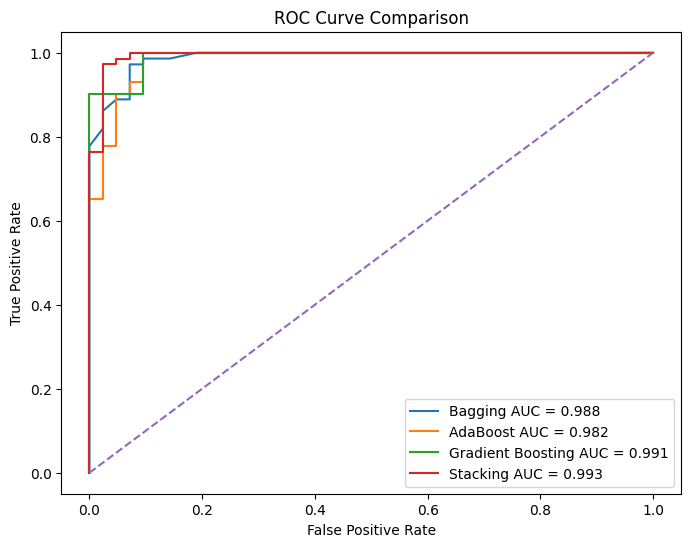

In [26]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_bag,
    tpr_bag,
    label=f"Bagging AUC = {roc_auc_score(y_test, bagging_prob):.3f}"
)

plt.plot(
    fpr_ada,
    tpr_ada,
    label=f"AdaBoost AUC = {roc_auc_score(y_test, ada_prob):.3f}"
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"Gradient Boosting AUC = {roc_auc_score(y_test, gb_prob):.3f}"
)

plt.plot(
    fpr_stack,
    tpr_stack,
    label=f"Stacking AUC = {roc_auc_score(y_test, stack_prob):.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

11)CONFUSION MATRIX 

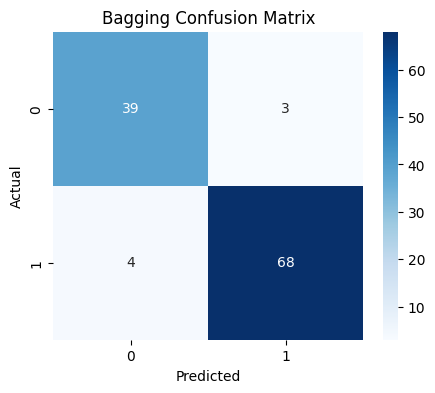

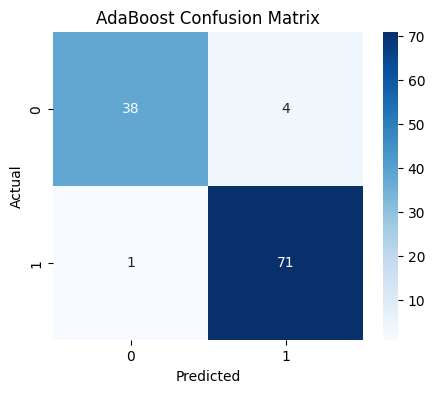

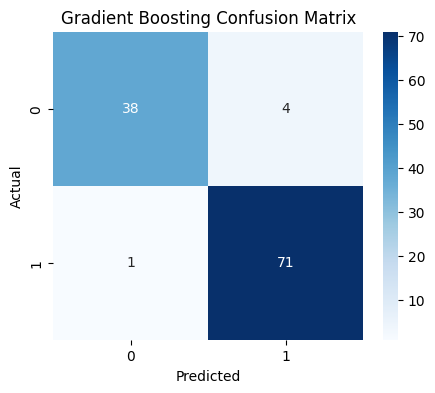

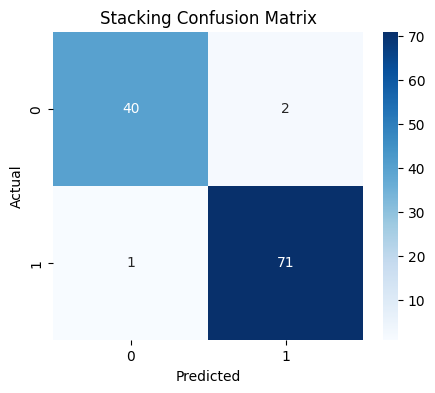

In [27]:
# Confusion matrices
cm_bagging = confusion_matrix(y_test, y_pred_bagging)
cm_adaboost = confusion_matrix(y_test, y_pred_ada)
cm_gradient = confusion_matrix(y_test, y_pred_gb)
cm_stacking = confusion_matrix(y_test, y_pred_stack)


# Bagging
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bagging, annot=True, fmt="d", cmap="Blues")
plt.title("Bagging Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# AdaBoost
plt.figure(figsize=(5, 4))
sns.heatmap(cm_adaboost, annot=True, fmt="d", cmap="Blues")
plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Gradient Boosting
plt.figure(figsize=(5, 4))
sns.heatmap(cm_gradient, annot=True, fmt="d", cmap="Blues")
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Stacking
plt.figure(figsize=(5, 4))
sns.heatmap(cm_stacking, annot=True, fmt="d", cmap="Blues")
plt.title("Stacking Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

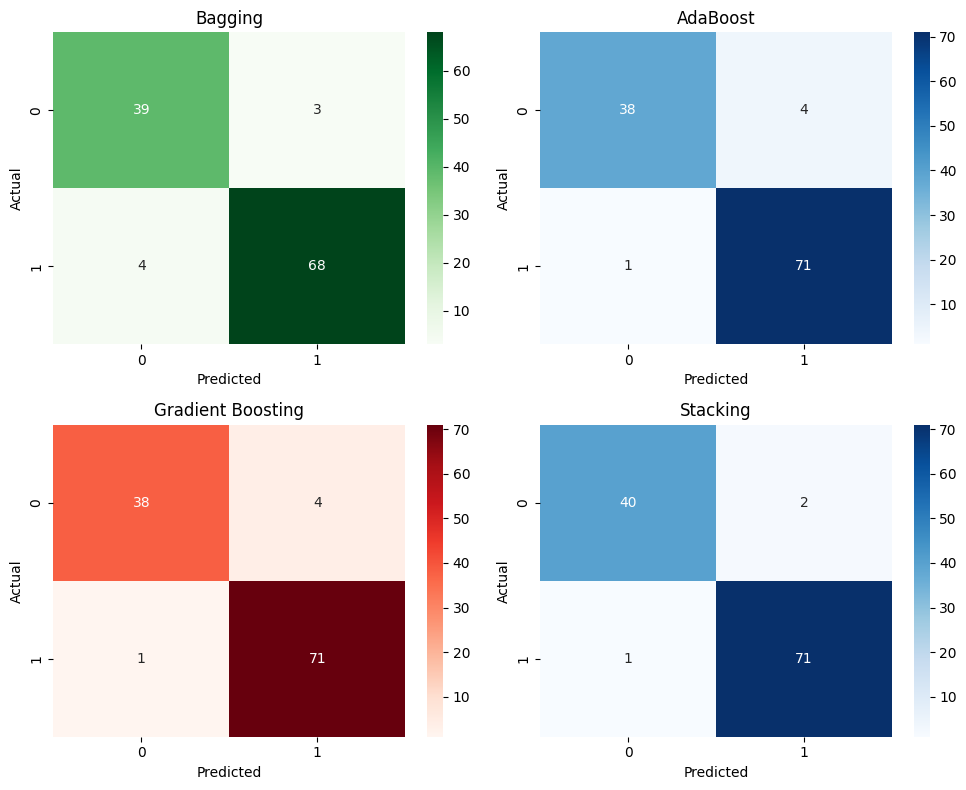

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Bagging
sns.heatmap(
    cm_bagging,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Bagging")
axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("Actual")


# AdaBoost
sns.heatmap(
    cm_adaboost,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0, 1]
)
axes[0, 1].set_title("AdaBoost")
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Actual")


# Gradient Boosting
sns.heatmap(
    cm_gradient,
    annot=True,
    fmt="d",
    cmap="Reds",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Gradient Boosting")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("Actual")


# Stacking
sns.heatmap(
    cm_stacking,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Stacking")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("Actual")

plt.tight_layout()
plt.show()